# QQQ Market Insight Pipeline 5 Year Experiment

**Stage-by-stage learning and report-writing notebook**  
**Student:** D6900557 Tien Hanprab  
**Reference implementation:** `src/pipeline_qqq_5_year.py`

ไฟล์ `_ex` เป็นอีกมุมมองหนึ่งของ pipeline เดียวกัน โดยจัดกลุ่มงานเป็น Stage 1–12 สำหรับรันทีละ cell ทุกค่าคำนวณหลักเรียกจากไฟล์ Python อ้างอิง จึงใช้สูตร features, split, models และ random seed ชุดเดียวกับ `pipeline_qqq_5_year.ipynb`

**วิธีใช้:** เริ่มจาก Stage 1 แล้วรัน cell ตามลำดับ หลีกเลี่ยงการข้าม Stage เพราะตัวแปรของแต่ละ Stage ถูกส่งต่อไปยัง Stage ถัดไป

## Stage 1 Setup and reference implementation

In [24]:
from pathlib import Path
import importlib
import json
import os
import sys

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display
from sklearn.base import clone
from sklearn.inspection import permutation_importance
from sklearn.metrics import RocCurveDisplay, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit, cross_validate


def find_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "config.json").exists() and (candidate / "src" / "pipeline_qqq_5_year.py").exists():
            return candidate
    raise FileNotFoundError("Cannot find the qqq-market-insight project root")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import pipeline_qqq_5_year as pipeline
pipeline = importlib.reload(pipeline)

# The reference script uses a non-interactive backend for command-line runs.
# Restore Jupyter's inline backend so notebook-only figures appear in cells.
get_ipython().run_line_magic("matplotlib", "inline")

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")
sns.set_theme(style="whitegrid", context="notebook")

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference script: {pipeline.__file__}")

Project root: /Users/tien/Development/PhD_SUT_ENG552209_BigDataAnalytics/qqq-market-insight
Reference script: /Users/tien/Development/PhD_SUT_ENG552209_BigDataAnalytics/qqq-market-insight/src/pipeline_qqq_5_year.py


## Stage 2 Configuration and source provenance

Notebook นี้เลือก `profiles.5_year` อย่างชัดเจนให้ตรงกับ raw path ของไฟล์ 5 ปี แม้ `active_profile` ใน `config.json` จะถูกสลับไปใช้การทดลองชุดอื่น

In [25]:
# This notebook is intentionally bound to the 5_year data paths in the
# reference module, even when config.json selects another CLI profile.
with pipeline.DEFAULT_CONFIG_PATH.open(encoding="utf-8") as config_file:
    cleaned_config = "\n".join(
        line for line in config_file if not line.lstrip().startswith("//")
    )
project_config = json.loads(cleaned_config)
config = dict(project_config["profiles"]["5_year"])
config["active_profile_name"] = "5_year"
metadata, raw_sha256 = pipeline._validate_cached_raw(config)

config_table = pd.DataFrame(
    [
        ("Symbol", config["symbol"]),
        ("Notebook profile", config["active_profile_name"]),
        ("Asset class", config["asset_class"]),
        ("Configured start", config["start_date"]),
        ("Configured end", config["end_date"]),
        ("Test fraction", f"{config['test_fraction']:.0%}"),
        ("Random seed", config["random_state"]),
        ("Permutation repeats", config["permutation_repeats"]),
        ("Source reference", metadata["source_reference_url"]),
        ("Final API request", metadata["request_url"]),
        ("Retrieved at UTC", metadata["retrieved_at_utc"]),
        ("Raw SHA-256", raw_sha256),
    ],
    columns=["Setting", "Value"],
)
display(config_table)

,Setting,Value
0,Symbol,QQQ
1,Notebook profile,5_year
2,Asset class,etf
3,Configured start,2021-01-01
4,Configured end,2026-09-17
5,Test fraction,20%
6,Random seed,42
7,Permutation repeats,30
8,Source reference,https://www.nasdaq.com/market-activity/etf/qqq...
9,Final API request,https://api.nasdaq.com/api/quote/QQQ/historica...


### Optional data download

ค่าเริ่มต้นใช้ raw response ที่เก็บไว้และไม่เชื่อมต่อเครือข่าย เปลี่ยน `DOWNLOAD_FRESH_DATA` เฉพาะเมื่อต้องการแทนที่ raw response และ metadata โดยตั้งใจ

In [26]:
DOWNLOAD_FRESH_DATA = False

if DOWNLOAD_FRESH_DATA:
    pipeline.download_data(force=True)
    print("Downloaded a new raw response and provenance metadata.")
else:
    print("Using the preserved raw Nasdaq response; no network request was made.")

Using the preserved raw Nasdaq response; no network request was made.


## Stage 3 Parse clean and audit OHLCV data

In [27]:
clean_ohlcv = pipeline.parse_raw()
cleaning_quality = dict(clean_ohlcv.attrs["quality"])

coverage_table = pd.DataFrame(
    {
        "Measure": ["Clean rows", "First trading date", "Last trading date", "Duplicate dates", "Invalid rows removed"],
        "Value": [
            len(clean_ohlcv),
            clean_ohlcv["Date"].min().date().isoformat(),
            clean_ohlcv["Date"].max().date().isoformat(),
            cleaning_quality["duplicate_date_rows_removed"],
            cleaning_quality["invalid_rows_removed"],
        ],
    }
)
display(coverage_table)
display(clean_ohlcv.head(5))
display(pd.DataFrame({"dtype": clean_ohlcv.dtypes.astype(str)}))

assert len(clean_ohlcv) >= 500
assert clean_ohlcv["Date"].is_monotonic_increasing
assert not clean_ohlcv["Date"].duplicated().any()
assert cleaning_quality["invalid_rows_removed"] == 0
print("Data quality gate passed: at least 500 unique chronological rows and no unexplained invalid OHLCV records.")

,Measure,Value
0,Clean rows,1433
1,First trading date,2021-01-04
2,Last trading date,2026-09-17
3,Duplicate dates,0
4,Invalid rows removed,0


,Date,Open,High,Low,Close,Volume
0,2021-01-04,315.110000,315.290000,305.180000,309.310000,45305900
1,2021-01-05,308.290000,312.140000,308.290000,311.860000,29323410
2,2021-01-06,307.000000,311.880000,305.980000,307.540000,52809620
3,2021-01-07,310.280000,315.840000,310.250000,314.980000,30394830
4,2021-01-08,317.340000,319.390000,315.081400,319.030000,33955850


,dtype
Date,datetime64[ns]
Open,float64
High,float64
Low,float64
Close,float64
Volume,int64


Data quality gate passed: at least 500 unique chronological rows and no unexplained invalid OHLCV records.


In [28]:
quality_rows = [
    ("Raw rows", cleaning_quality["raw_rows"]),
    ("Duplicate-date rows removed", cleaning_quality["duplicate_date_rows_removed"]),
    ("Invalid rows removed", cleaning_quality["invalid_rows_removed"]),
    ("Clean OHLCV rows", cleaning_quality["clean_ohlcv_rows"]),
    ("Missing-value rows removed", cleaning_quality["rows_with_missing_values_removed"]),
    ("Nonpositive price or negative-volume rows removed", cleaning_quality["rows_with_nonpositive_price_or_negative_volume_removed"]),
    ("Invalid High rows removed", cleaning_quality["rows_with_invalid_high_removed"]),
    ("Invalid Low rows removed", cleaning_quality["rows_with_invalid_low_removed"]),
]
display(pd.DataFrame(quality_rows, columns=["Quality check", "Rows"]))

,Quality check,Rows
0,Raw rows,1433
1,Duplicate-date rows removed,0
2,Invalid rows removed,0
3,Clean OHLCV rows,1433
4,Missing-value rows removed,0
5,Nonpositive price or negative-volume rows removed,0
6,Invalid High rows removed,0
7,Invalid Low rows removed,0


## Stage 4 Feature engineering and target

ใช้ `pipeline.add_features()` เพื่อให้ตัวชี้วัด 21 ตัวและ target แบบ next trading day ตรงกับ reference implementation

In [29]:
model_data = pipeline.add_features(clean_ohlcv)
feature_quality = dict(model_data.attrs["quality"])

feature_catalog = pd.DataFrame(
    [(family, feature) for family, features in pipeline.FEATURE_GROUPS.items() for feature in features],
    columns=["Feature family", "Feature"],
)
display(feature_catalog.groupby("Feature family")["Feature"].apply(lambda values: ", ".join(values)).to_frame())

feature_audit = pd.DataFrame(
    {
        "Measure": ["Technical indicators", "Model-ready rows", "Warm-up rows removed", "Terminal target rows removed", "Remaining feature missing values"],
        "Value": [
            len(pipeline.FEATURES),
            len(model_data),
            feature_quality["feature_warmup_rows_removed"],
            feature_quality["terminal_target_rows_removed"],
            int(model_data[pipeline.FEATURES].isna().sum().sum()),
        ],
    }
)
display(feature_audit)
display(model_data[["Date", "Open", "High", "Low", "Close", "Volume", "next_return", "target_up", *pipeline.FEATURES[:5]]].head())

,Feature
Feature family,
Momentum,"rsi_14, stoch_k_14, roc_10"
Return history,"return_1d, return_5d, gap_return"
Trend,"sma_ratio_5, sma_ratio_10, sma_ratio_20, sma_c..."
Volatility,"range_pct, atr_14_pct, volatility_10, volatili..."
Volume,"volume_change, volume_ratio_20, obv_change_5"


,Measure,Value
0,Technical indicators,21
1,Model-ready rows,1412
2,Warm-up rows removed,20
3,Terminal target rows removed,1
4,Remaining feature missing values,0


,Date,Open,High,Low,Close,Volume,next_return,target_up,return_1d,return_5d,gap_return,sma_ratio_5,sma_ratio_10
0,2021-02-02,325.480000,328.870000,325.310000,327.680000,33930840,-0.003967,0,0.016314,-0.002769,0.009491,0.020549,0.012089
1,2021-02-03,329.820000,330.195000,326.320000,326.380000,24824520,0.011827,1,-0.003967,0.021758,0.006531,0.012119,0.007262
2,2021-02-04,327.820000,330.330000,326.460000,330.240000,22350950,0.003391,1,0.011827,0.027760,0.004412,0.018455,0.017955
3,2021-02-05,331.220000,332.402500,329.530000,331.360000,22731960,0.006700,1,0.003391,0.053408,0.002968,0.011428,0.019541
4,2021-02-08,333.100000,333.740000,331.410000,333.580000,20462810,-0.000210,0,0.006700,0.034613,0.005251,0.011314,0.024647


In [30]:
assert "next_return" not in pipeline.FEATURES
assert "target_up" not in pipeline.FEATURES
assert model_data[pipeline.FEATURES].notna().all().all()
assert set(model_data["target_up"].unique()) == {0, 1}

target_preview = model_data[["Date", "Close", "next_return", "target_up"]].tail(8).copy()
target_preview["next_return_pct"] = target_preview["next_return"] * 100
display(target_preview[["Date", "Close", "next_return_pct", "target_up"]])
print("Leakage gate passed: model features exclude next_return and target_up.")

,Date,Close,next_return_pct,target_up
1404,2026-09-04,718.960000,-0.083454,0
1405,2026-09-08,718.360000,-0.285372,0
1406,2026-09-09,716.310000,-1.063785,0
1407,2026-09-10,708.690000,0.873443,1
1408,2026-09-11,714.880000,-0.797337,0
1409,2026-09-14,709.180000,-0.654277,0
1410,2026-09-15,704.540000,0.025549,1
1411,2026-09-16,704.720000,1.731184,1


Leakage gate passed: model features exclude next_return and target_up.


## Stage 5 Chronological train test split and leakage check

In [31]:
label_dates = pd.Series(
    clean_ohlcv["Date"].shift(-1).to_numpy(), index=clean_ohlcv["Date"]
).reindex(model_data["Date"]).reset_index(drop=True)

split_index = int(len(model_data) * (1 - config["test_fraction"]))
train_data = model_data.iloc[: split_index - 1].copy()
gap_data = model_data.iloc[split_index - 1 : split_index].copy()
test_data = model_data.iloc[split_index:].copy()

assert train_data["Date"].max() < test_data["Date"].min()
assert label_dates.iloc[split_index - 2] < test_data["Date"].min()

split_table = pd.DataFrame(
    [
        ("Train", len(train_data), train_data["Date"].min().date(), train_data["Date"].max().date()),
        ("Boundary gap", len(gap_data), gap_data["Date"].min().date(), gap_data["Date"].max().date()),
        ("Test", len(test_data), test_data["Date"].min().date(), test_data["Date"].max().date()),
    ],
    columns=["Partition", "Rows", "Start", "End"],
)
display(split_table)
print("Chronological split passed: the one-row boundary gap prevents a training label from reaching the held-out test period.")

,Partition,Rows,Start,End
0,Train,1128,2021-02-02,2025-07-30
1,Boundary gap,1,2025-07-31,2025-07-31
2,Test,283,2025-08-01,2026-09-16


Chronological split passed: the one-row boundary gap prevents a training label from reaching the held-out test period.


## Stage 6 Exploratory data analysis

EDA ใช้ training period เท่านั้น รูปหกประเภทแรกสร้างจาก `pipeline.save_eda(train_data)` แล้วแสดง inline แยกเป็น cell เพื่อใช้เขียนรายงาน

In [32]:
pipeline.save_eda(train_data)
print(f"Saved six training-period EDA figures to: {pipeline.FIGURES_PATH}")

ValueError: Invalid frequency: YE

### Figure 1 Price trend and moving average

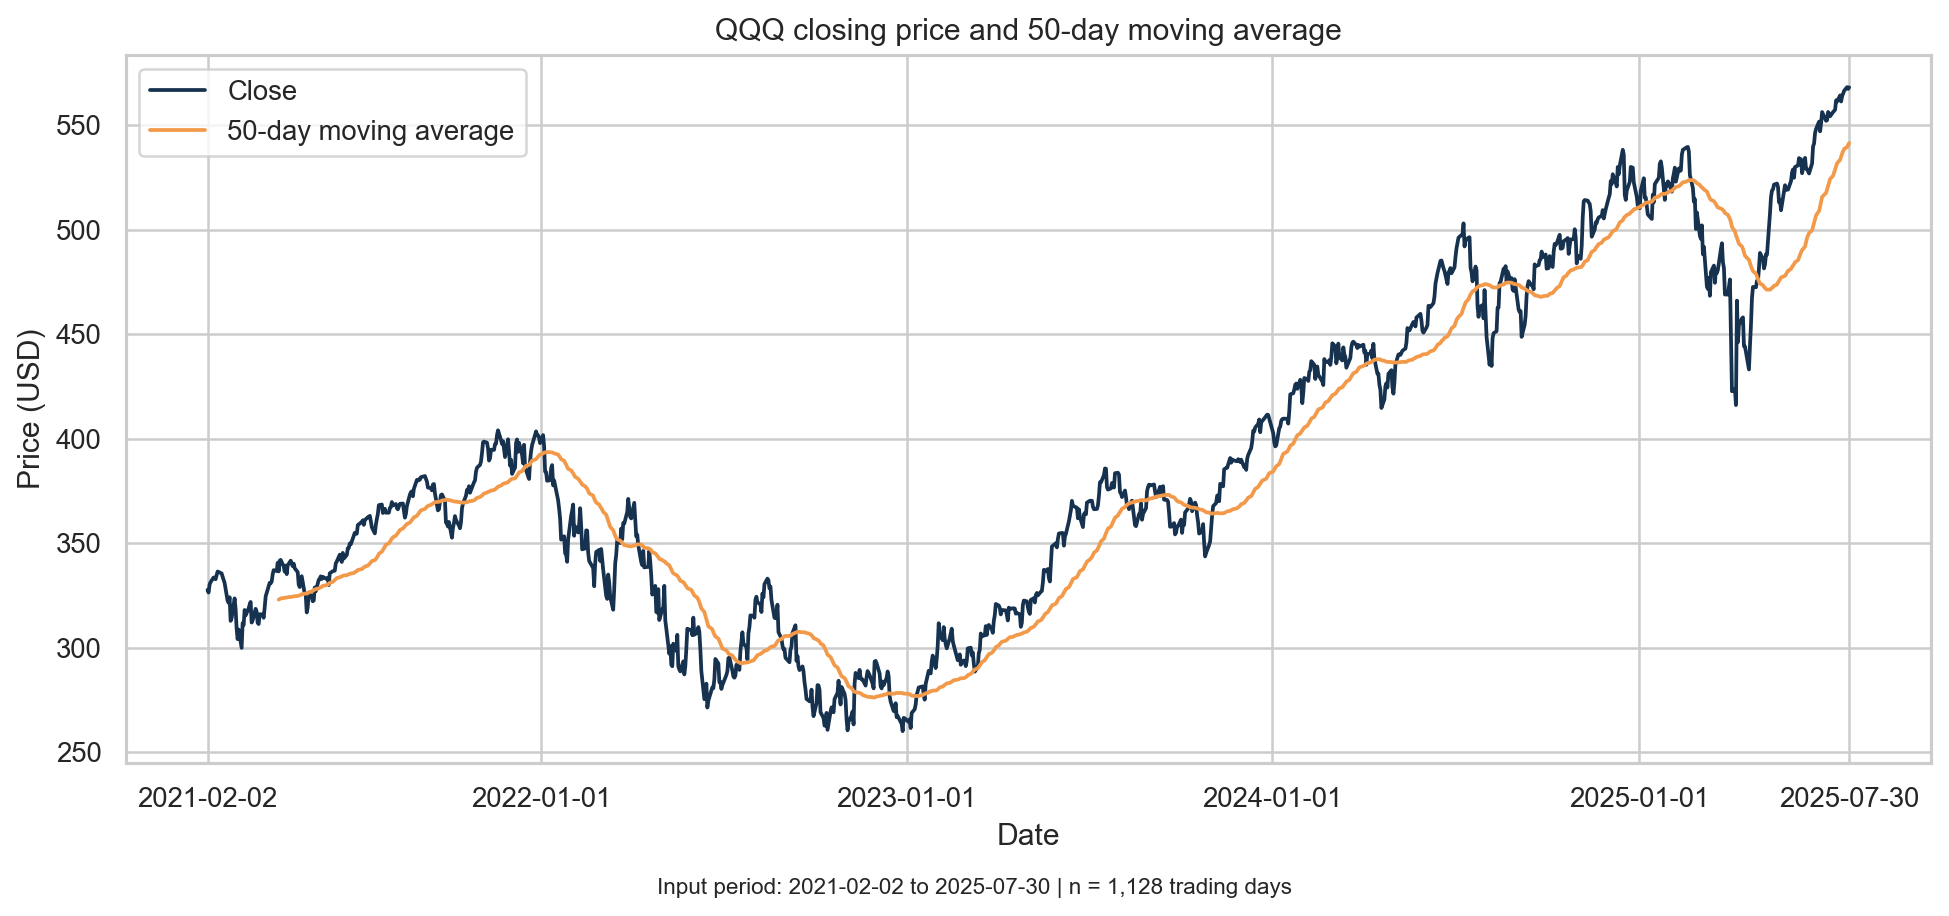

Training-period Close moved from $327.68 to $568.02 (73.35%). Minimum $260.10; maximum $568.14.


In [33]:
display(Image(filename=str(pipeline.FIGURES_PATH / "01_price_trend.png")))
price_change = train_data["Close"].iloc[-1] / train_data["Close"].iloc[0] - 1
print(
    f"Training-period Close moved from ${train_data['Close'].iloc[0]:,.2f} to "
    f"${train_data['Close'].iloc[-1]:,.2f} ({price_change:.2%}). "
    f"Minimum ${train_data['Close'].min():,.2f}; maximum ${train_data['Close'].max():,.2f}."
)

### Figure 2 Daily return distribution

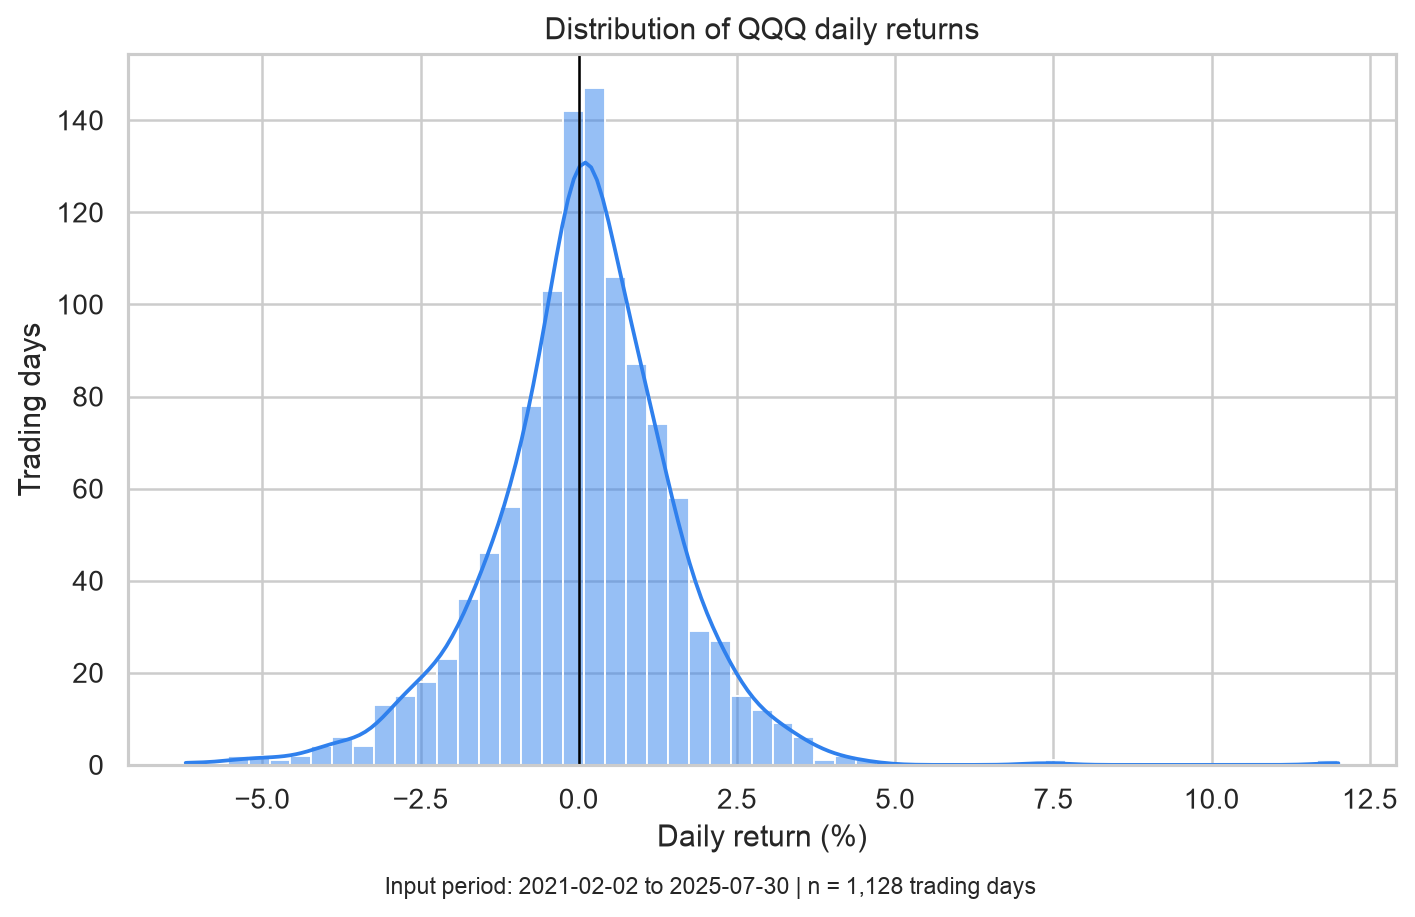

Mean daily return = 0.0609%; standard deviation = 1.4621%; minimum = -6.2109%; maximum = 12.0031%.


In [11]:
display(Image(filename=str(pipeline.FIGURES_PATH / "02_return_distribution.png")))
daily_return_pct = train_data["return_1d"] * 100
print(
    f"Mean daily return = {daily_return_pct.mean():.4f}%; "
    f"standard deviation = {daily_return_pct.std():.4f}%; "
    f"minimum = {daily_return_pct.min():.4f}%; maximum = {daily_return_pct.max():.4f}%."
)

### Figure 3 Monthly return dispersion

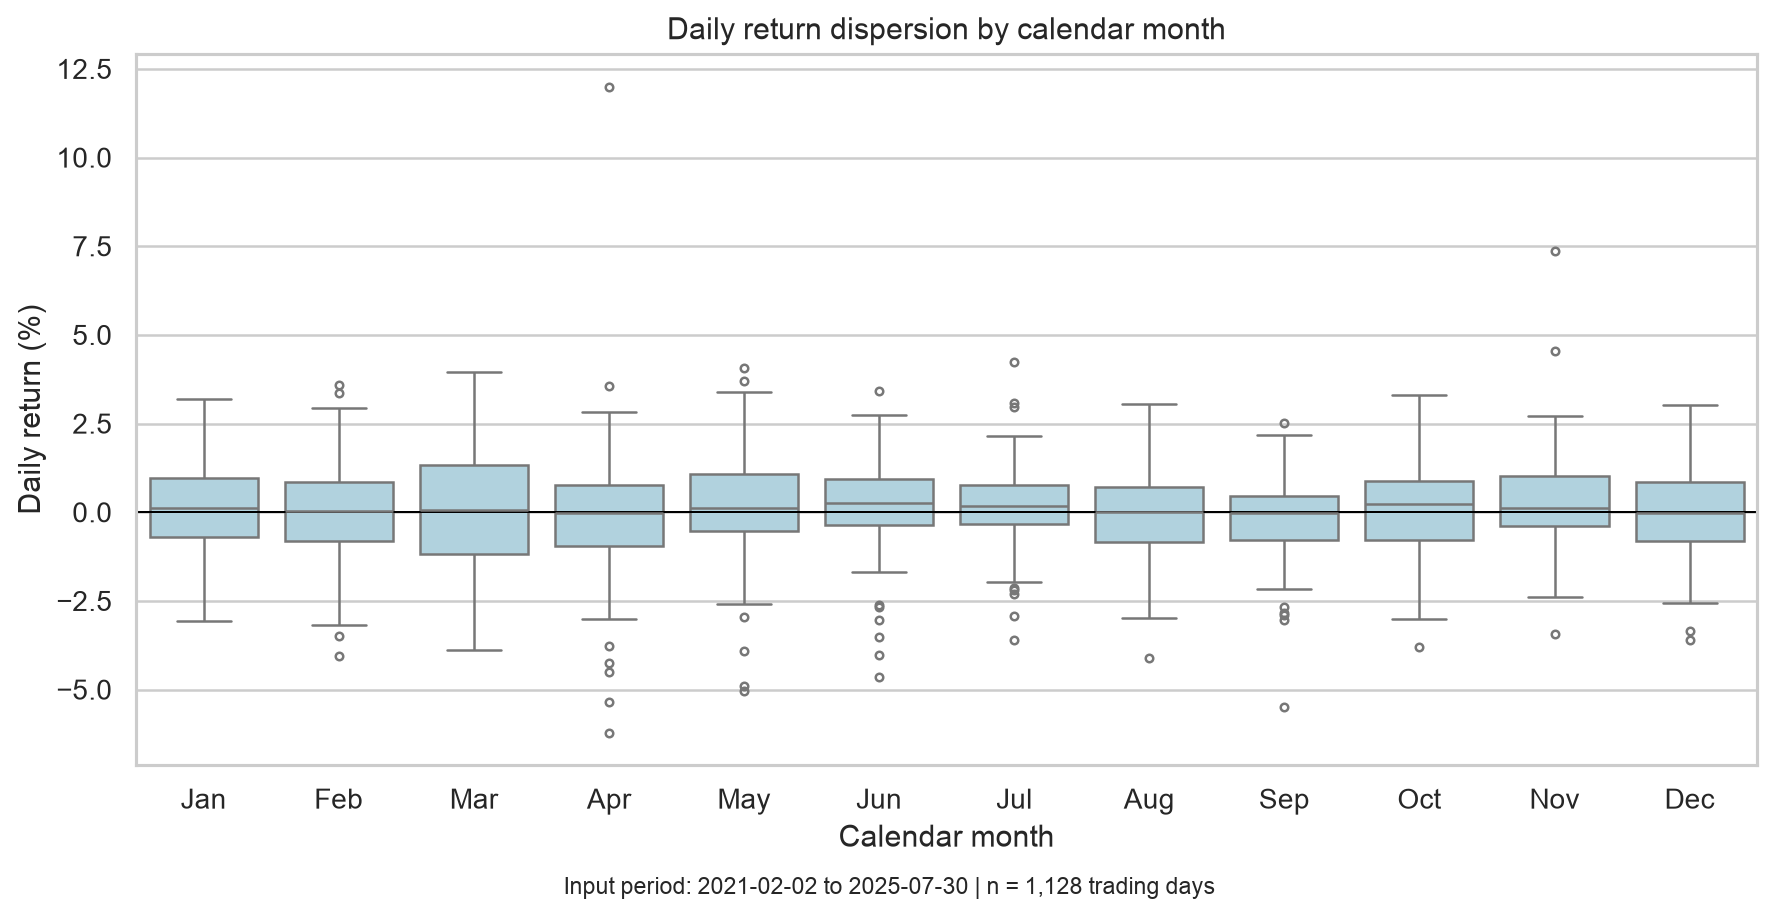

,observations,median_pct,standard_deviation_pct
month,,,
Apr,103,-0.0126,2.0769
Mar,110,0.0546,1.6210
May,106,0.1140,1.5258
Feb,95,0.0278,1.4547
Nov,83,0.1168,1.4540


In [12]:
display(Image(filename=str(pipeline.FIGURES_PATH / "03_monthly_boxplot.png")))
monthly_dispersion = (
    train_data.assign(month=train_data["Date"].dt.strftime("%b"), return_pct=train_data["return_1d"] * 100)
    .groupby("month")["return_pct"]
    .agg(observations="count", median_pct="median", standard_deviation_pct="std")
    .sort_values("standard_deviation_pct", ascending=False)
)
display(monthly_dispersion.head(5).style.format({"median_pct": "{:.4f}", "standard_deviation_pct": "{:.4f}"}))

### Figure 4 RSI and next day return

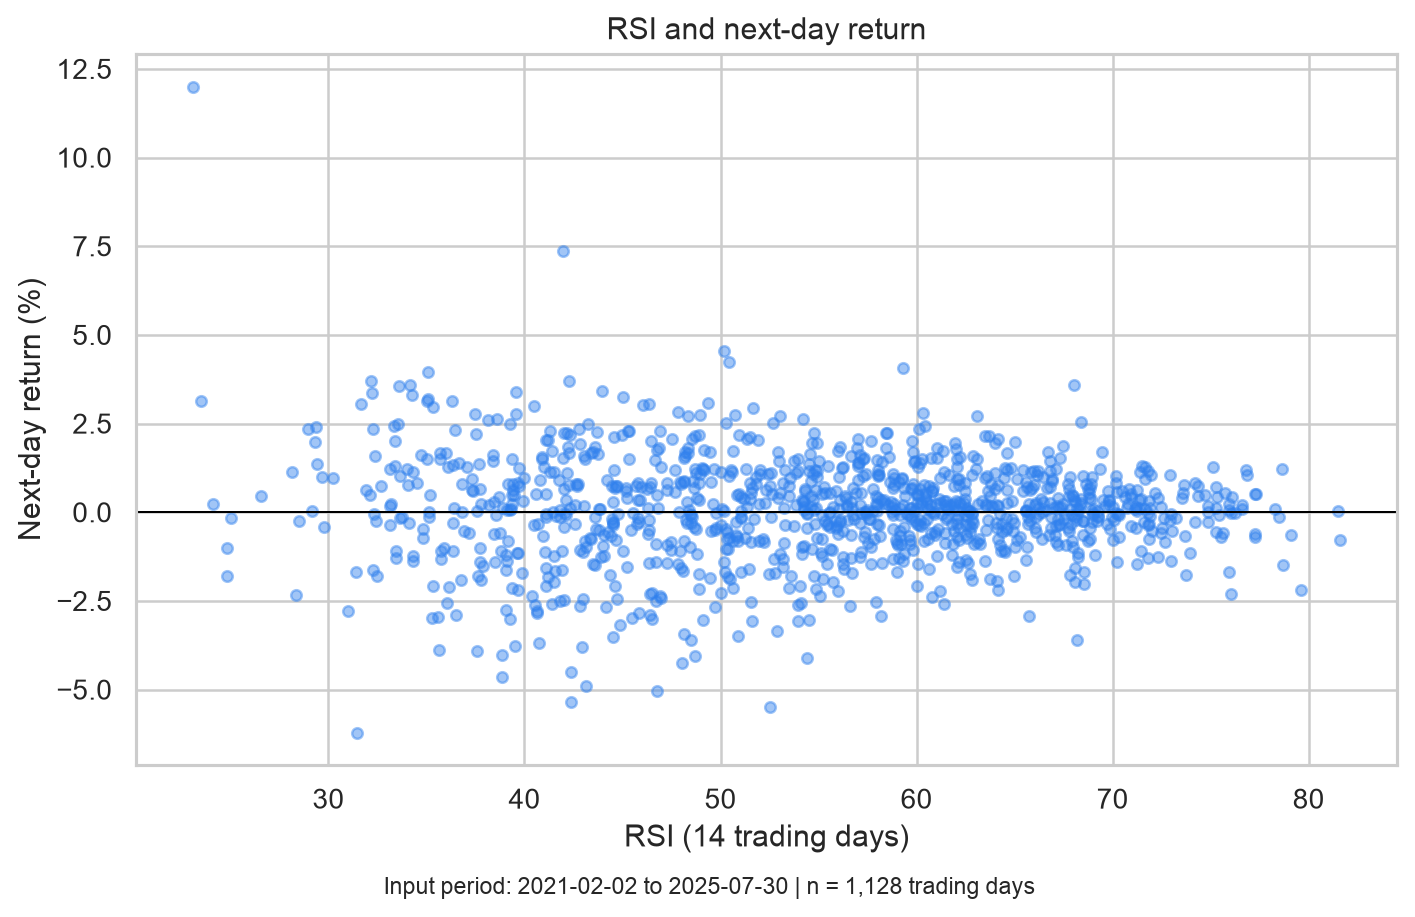

Pearson correlation between RSI(14) and next-day return = -0.0312.


In [13]:
display(Image(filename=str(pipeline.FIGURES_PATH / "04_rsi_scatter.png")))
rsi_next_correlation = train_data[["rsi_14", "next_return"]].corr().iloc[0, 1]
print(f"Pearson correlation between RSI(14) and next-day return = {rsi_next_correlation:.4f}.")

### Figure 5 Technical indicator correlation

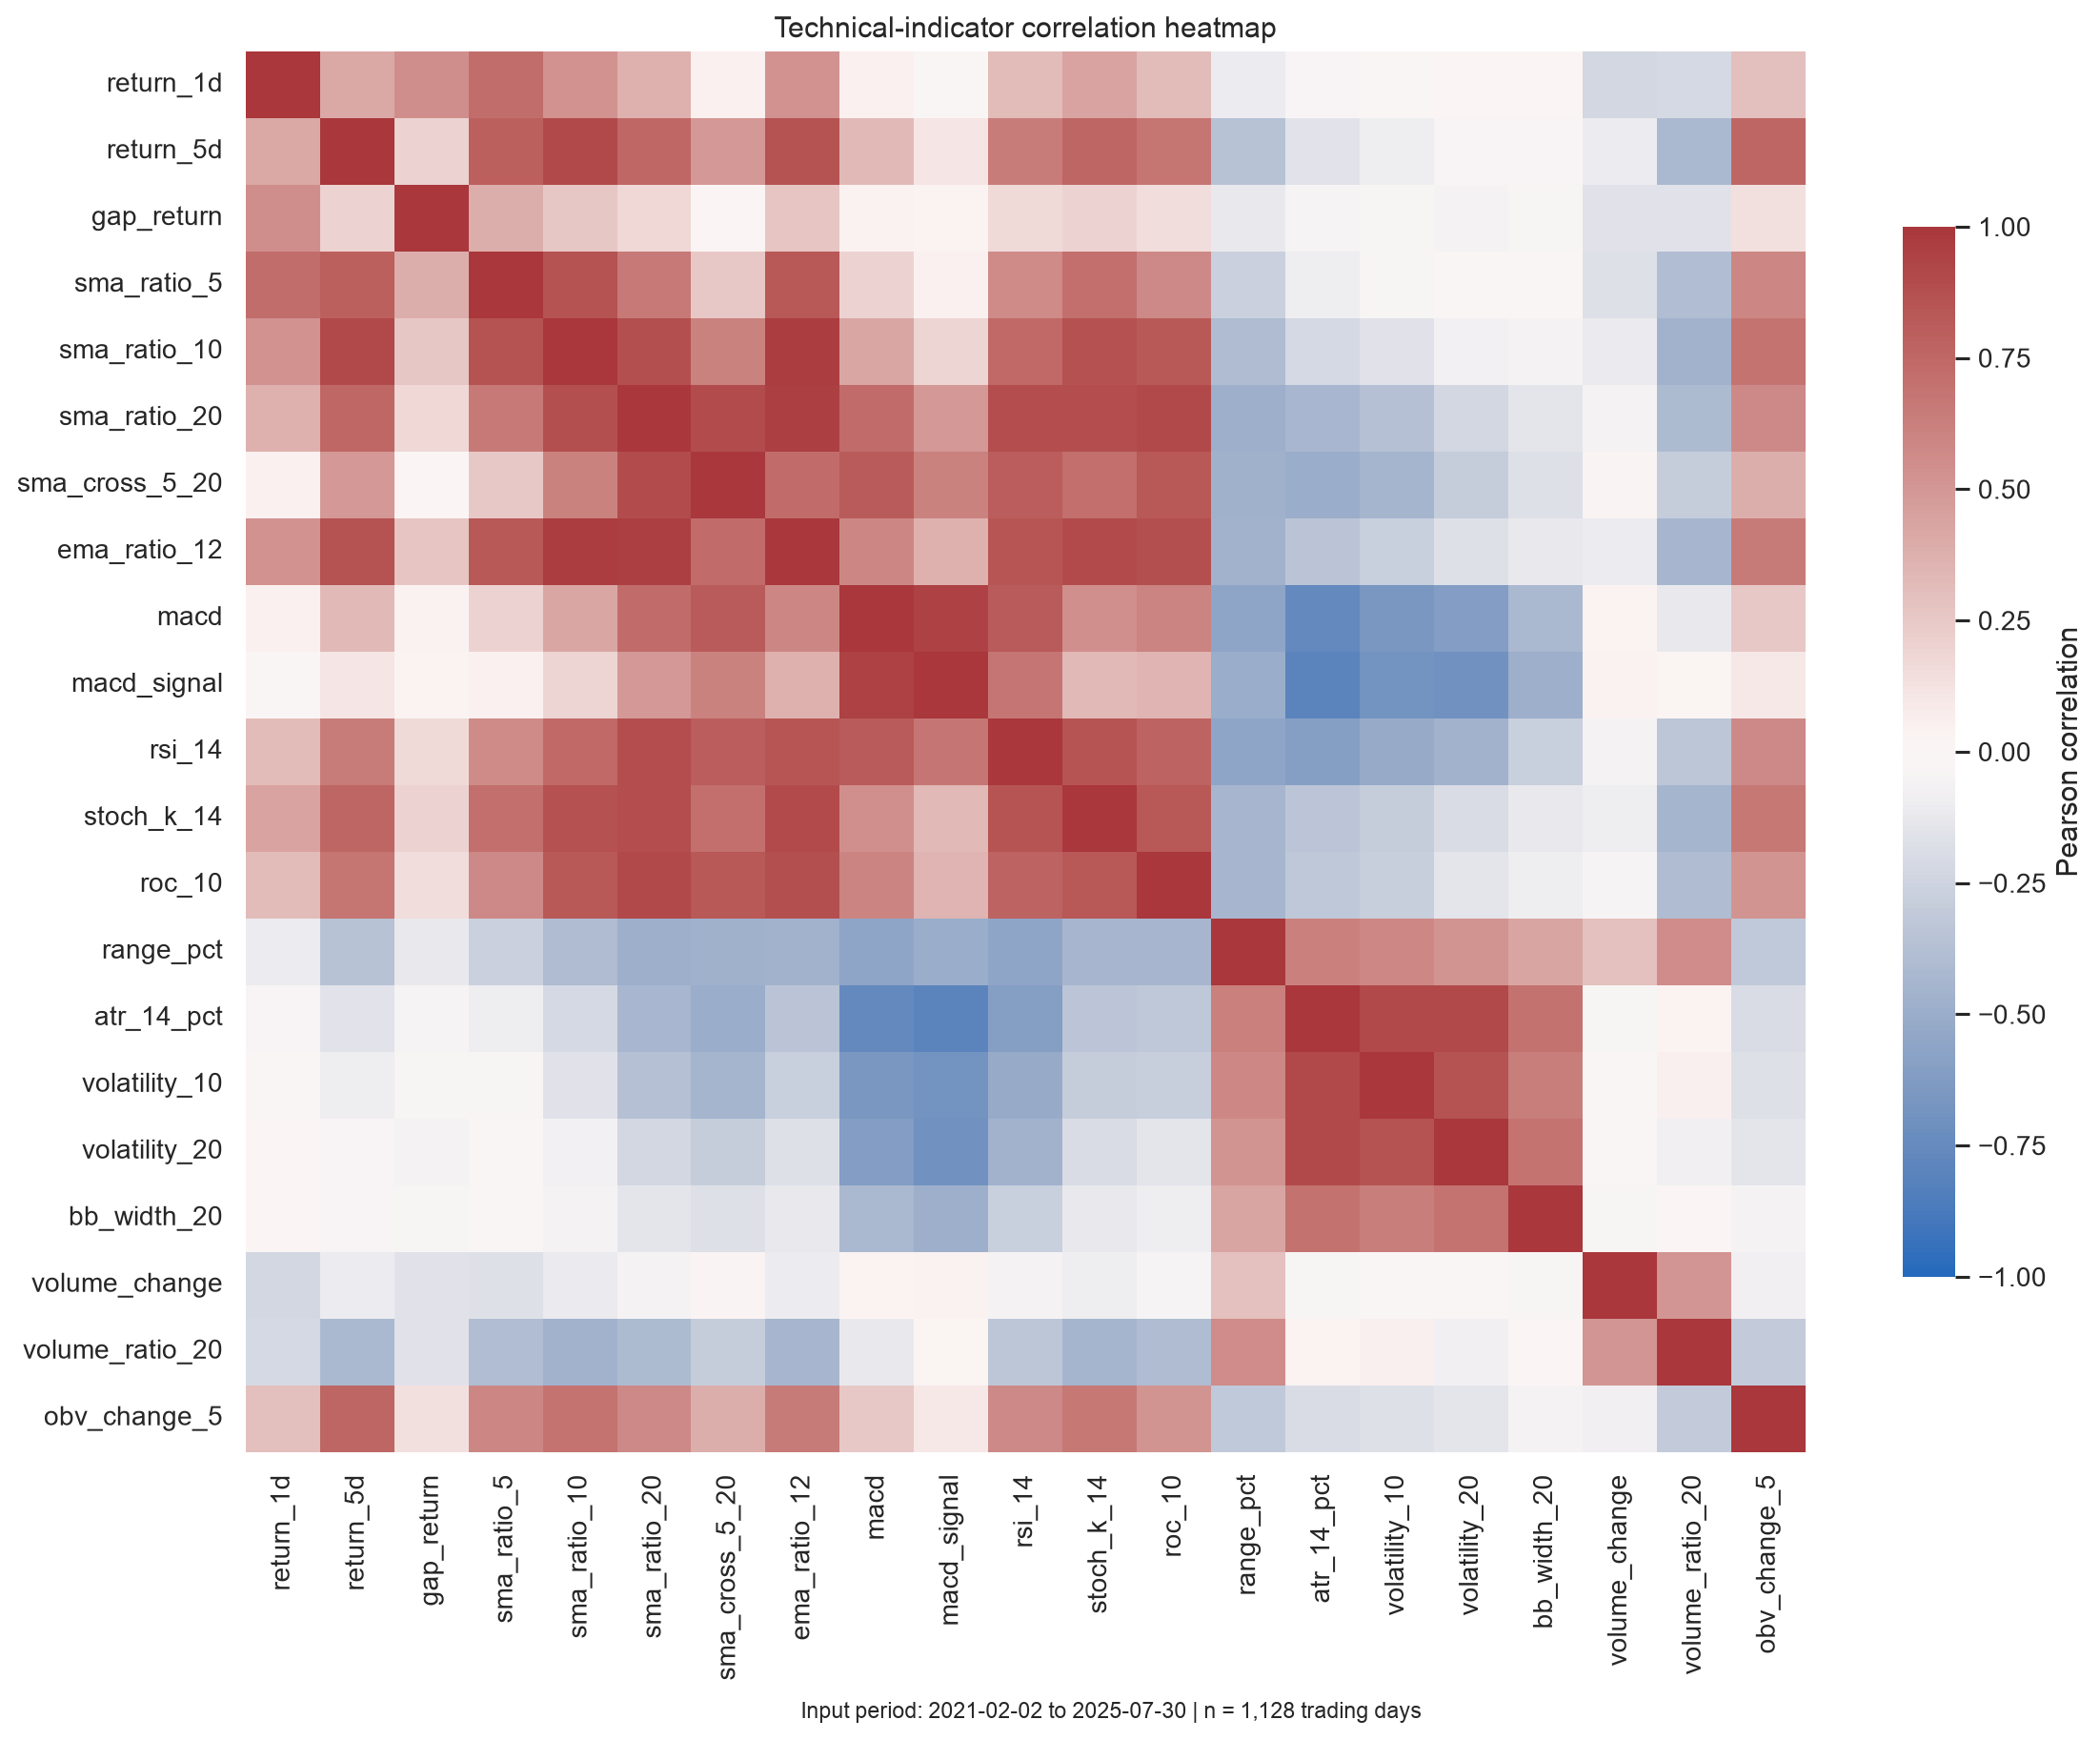

,feature_1,feature_2,correlation,abs_correlation
76,sma_ratio_10,ema_ratio_12,0.9694,0.9694
91,sma_ratio_20,ema_ratio_12,0.9554,0.9554
132,macd,macd_signal,0.9506,0.9506
189,atr_14_pct,volatility_10,0.9141,0.9141
96,sma_ratio_20,roc_10,0.9137,0.9137
22,return_5d,sma_ratio_10,0.9133,0.9133
190,atr_14_pct,volatility_20,0.9122,0.9122
122,ema_ratio_12,stoch_k_14,0.9031,0.9031


In [14]:
display(Image(filename=str(pipeline.FIGURES_PATH / "05_correlation_heatmap.png")))
correlation_matrix = train_data[pipeline.FEATURES].corr()
upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))
strongest_pairs = (
    upper_triangle.stack().rename("correlation").reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
    .assign(abs_correlation=lambda frame: frame["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
    .head(8)
)
display(strongest_pairs.style.format({"correlation": "{:.4f}", "abs_correlation": "{:.4f}"}))

### Figure 6 Target class balance

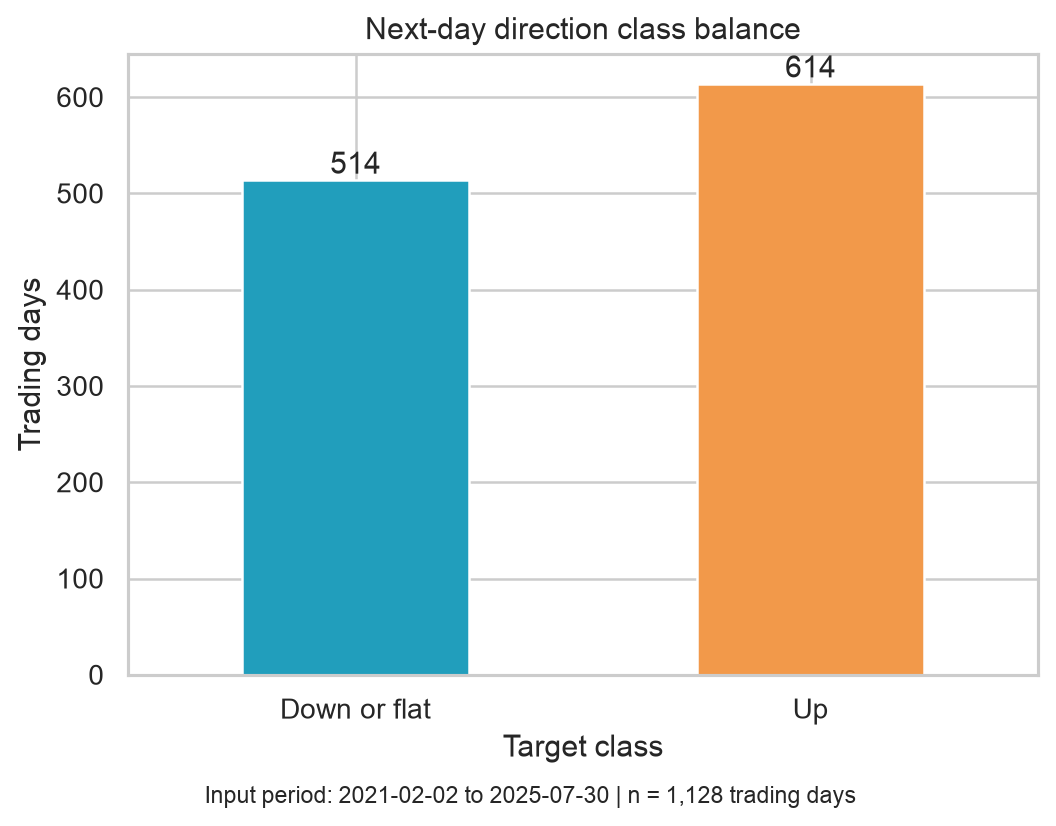

,Rows,Share
Class,,
Down or flat,514,45.57%
Up,614,54.43%


In [15]:
display(Image(filename=str(pipeline.FIGURES_PATH / "06_class_balance.png")))
class_balance = (
    train_data["target_up"].map({0: "Down or flat", 1: "Up"})
    .value_counts().reindex(["Down or flat", "Up"], fill_value=0)
    .rename_axis("Class").to_frame("Rows")
)
class_balance["Share"] = class_balance["Rows"] / class_balance["Rows"].sum()
display(class_balance.style.format({"Share": "{:.2%}"}))

### Figure 7 Volume and rolling volatility

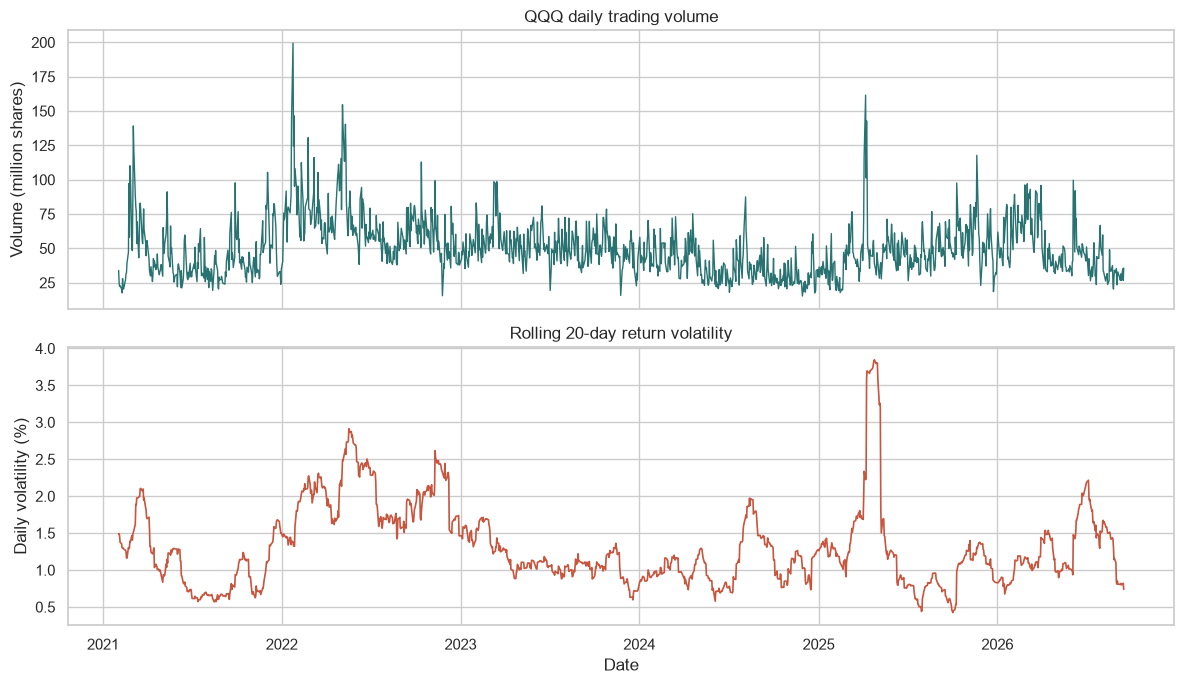

Full model-ready period 2021-02-02 to 2026-09-16: average volume 50.14 million shares; median volume 46.71 million shares; maximum 20-day daily volatility 3.85%.


*This full-period chart is a retrospective description for Research Question 1; model development and EDA choices above use the training period only.*

In [16]:
full_period = model_data.copy()
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(full_period["Date"], full_period["Volume"] / 1_000_000, color="#287271", linewidth=1)
axes[0].set_title("QQQ daily trading volume")
axes[0].set_ylabel("Volume (million shares)")
axes[1].plot(full_period["Date"], full_period["volatility_20"] * 100, color="#C8553D", linewidth=1.2)
axes[1].set_title("Rolling 20-day return volatility")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Daily volatility (%)")
plt.tight_layout()
plt.show()

print(
    f"Full model-ready period {full_period['Date'].min():%Y-%m-%d} to {full_period['Date'].max():%Y-%m-%d}: "
    f"average volume {full_period['Volume'].mean()/1_000_000:,.2f} million shares; "
    f"median volume {full_period['Volume'].median()/1_000_000:,.2f} million shares; "
    f"maximum 20-day daily volatility {full_period['volatility_20'].max()*100:.2f}%."
)
display(Markdown("*This full-period chart is a retrospective description for Research Question 1; model development and EDA choices above use the training period only.*"))

## Stage 7 Train the four fixed models

In [17]:
x_train = train_data[pipeline.FEATURES]
y_train = train_data["target_up"]
x_test = test_data[pipeline.FEATURES]
y_test = test_data["target_up"]

fitted_models, model_metrics = pipeline.build_models(x_train, y_train, x_test, y_test, config=config)
metric_columns = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"]
display(
    model_metrics.style
    .format({column: "{:.4f}" for column in metric_columns})
    .highlight_max(subset=metric_columns, color="#D9EAD3")
)

,model,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
0,Majority baseline,0.5477,0.5000,0.5477,1.0000,0.7078,0.5000
1,Logistic regression,0.5088,0.5006,0.5482,0.5871,0.5670,0.4806
2,Random forest,0.5159,0.5098,0.5563,0.5742,0.5651,0.5034
3,GradientBoosting,0.5300,0.5274,0.5733,0.5548,0.5639,0.5269


### Compare every model with the majority baseline

In [18]:
baseline_metrics = model_metrics.set_index("model").loc["Majority baseline"]
comparison = model_metrics.set_index("model").copy()
comparison["accuracy_minus_baseline"] = comparison["accuracy"] - baseline_metrics["accuracy"]
comparison["balanced_accuracy_minus_baseline"] = comparison["balanced_accuracy"] - baseline_metrics["balanced_accuracy"]
display(
    comparison[["accuracy", "balanced_accuracy", "roc_auc", "accuracy_minus_baseline", "balanced_accuracy_minus_baseline"]]
    .style.format("{:.4f}")
)

rf_delta = comparison.loc["Random forest", "accuracy_minus_baseline"]
print(
    f"Random Forest accuracy differs from the majority baseline by {rf_delta:+.4f} "
    f"({rf_delta*100:+.2f} percentage points) on the unseen chronological test period."
)

,accuracy,balanced_accuracy,roc_auc,accuracy_minus_baseline,balanced_accuracy_minus_baseline
model,,,,,
Majority baseline,0.5477,0.5000,0.5000,0.0000,0.0000
Logistic regression,0.5088,0.5006,0.4806,-0.0389,0.0006
Random forest,0.5159,0.5098,0.5034,-0.0318,0.0098
GradientBoosting,0.5300,0.5274,0.5269,-0.0177,0.0274


Random Forest accuracy differs from the majority baseline by -0.0318 (-3.18 percentage points) on the unseen chronological test period.


## Stage 8 Detailed held out evaluation

ใช้ `GradientBoosting` ตาม reference pipeline ซึ่งภายในเป็น `HistGradientBoostingClassifier` การประเมินนี้เป็นผลเชิงพรรณนาบน chronological holdout ที่กำหนดไว้

,Predicted down or flat,Predicted up
Actual down or flat,64,64
Actual up,69,86


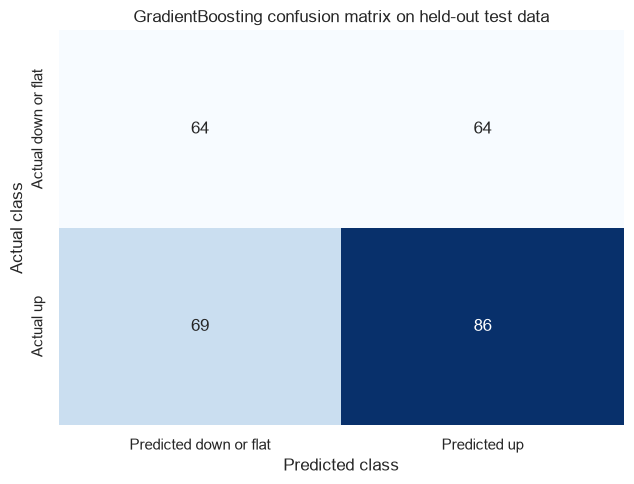

In [19]:
target_model_name = "GradientBoosting"
main_model = fitted_models[target_model_name]
main_prediction = main_model.predict(x_test)
main_probability = pipeline._positive_probability(main_model, x_test)

matrix = confusion_matrix(y_test, main_prediction, labels=[0, 1])
matrix_frame = pd.DataFrame(
    matrix,
    index=["Actual down or flat", "Actual up"],
    columns=["Predicted down or flat", "Predicted up"],
)
display(matrix_frame)

plt.figure(figsize=(6.5, 5))
sns.heatmap(matrix_frame, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title(f"{target_model_name} confusion matrix on held-out test data")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.tight_layout()
plt.show()

### ROC curves for learned models

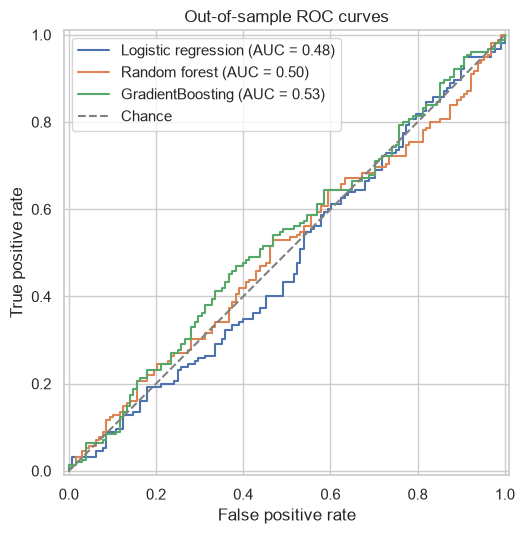

In [20]:
fig, axis = plt.subplots(figsize=(7.5, 5.5))
for model_name, fitted_model in fitted_models.items():
    if model_name != "Majority baseline":
        RocCurveDisplay.from_estimator(fitted_model, x_test, y_test, name=model_name, ax=axis)
axis.plot([0, 1], [0, 1], "--", color="gray", label="Chance")
axis.set_title("Out-of-sample ROC curves")
axis.set_xlabel("False positive rate")
axis.set_ylabel("True positive rate")
axis.legend()
plt.tight_layout()
plt.show()

## Stage 9 Expanding time series cross validation

In [21]:
time_series_cv = TimeSeriesSplit(n_splits=pipeline.CV_SPLITS, gap=pipeline.CV_GAP)
cv_result = cross_validate(
    clone(main_model),
    x_train,
    y_train,
    cv=time_series_cv,
    scoring=["accuracy", "balanced_accuracy", "f1", "roc_auc"],
    n_jobs=-1,
    error_score="raise",
)

cv_folds = pd.DataFrame(
    {key.removeprefix("test_"): value for key, value in cv_result.items() if key.startswith("test_")}
)
cv_folds.insert(0, "fold", range(1, len(cv_folds) + 1))

boundaries = []
for train_indices, validation_indices in time_series_cv.split(x_train):
    boundaries.append(
        {
            "train_rows": len(train_indices),
            "validation_rows": len(validation_indices),
            "train_end_date": train_data.iloc[train_indices[-1]]["Date"].date().isoformat(),
            "validation_start_date": train_data.iloc[validation_indices[0]]["Date"].date().isoformat(),
            "gap_rows": int(validation_indices[0] - train_indices[-1] - 1),
        }
    )
cv_folds = pd.concat([cv_folds, pd.DataFrame(boundaries)], axis=1)

cv_summary = pd.DataFrame(
    [
        {"metric": metric, "mean": cv_folds[metric].mean(), "standard_deviation": cv_folds[metric].std(ddof=1)}
        for metric in ("accuracy", "balanced_accuracy", "f1", "roc_auc")
    ]
)
display(cv_folds.style.format({metric: "{:.4f}" for metric in ("accuracy", "balanced_accuracy", "f1", "roc_auc")}))
display(cv_summary.style.format({"mean": "{:.4f}", "standard_deviation": "{:.4f}"}))

,fold,accuracy,balanced_accuracy,f1,roc_auc,train_rows,validation_rows,train_end_date,validation_start_date,gap_rows
0,1,0.5266,0.5331,0.6009,0.5136,187,188,2021-10-27,2021-10-29,1
1,2,0.4787,0.4718,0.3951,0.4882,375,188,2022-07-28,2022-08-01,1
2,3,0.5266,0.4994,0.6213,0.4926,563,188,2023-04-27,2023-05-01,1
3,4,0.5053,0.4875,0.5830,0.5026,751,188,2024-01-26,2024-01-30,1
4,5,0.5053,0.5144,0.5027,0.4856,939,188,2024-10-24,2024-10-28,1


,metric,mean,standard_deviation
0,accuracy,0.5085,0.0198
1,balanced_accuracy,0.5012,0.0237
2,f1,0.5406,0.0929
3,roc_auc,0.4965,0.0115


## Stage 10 Held out permutation feature importance

,feature,importance_mean,importance_std,family
14,atr_14_pct,0.0315,0.0085,Volatility
10,rsi_14,0.0127,0.0072,Momentum
12,roc_10,0.0121,0.0109,Momentum
16,volatility_20,0.0119,0.0153,Volatility
11,stoch_k_14,0.0114,0.0104,Momentum
6,sma_cross_5_20,0.0089,0.0073,Trend
13,range_pct,0.0085,0.0055,Volatility
17,bb_width_20,0.0063,0.0083,Volatility
1,return_5d,0.0049,0.0160,Return history
2,gap_return,0.0046,0.0097,Return history


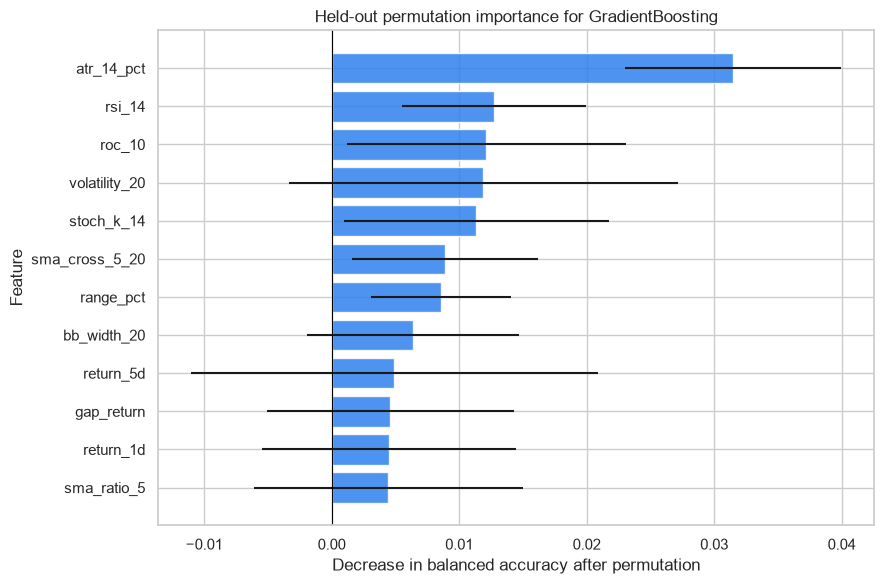

Error bars show ±1 standard deviation across permutations; they are not confidence intervals. Correlated indicators can divide importance between related features.

In [22]:
permutation = permutation_importance(
    main_model,
    x_test,
    y_test,
    n_repeats=config["permutation_repeats"],
    random_state=config["random_state"],
    scoring="balanced_accuracy",
    n_jobs=-1,
)

importance = pd.DataFrame(
    {
        "feature": pipeline.FEATURES,
        "importance_mean": permutation.importances_mean,
        "importance_std": permutation.importances_std,
    }
).sort_values("importance_mean", ascending=False)
family_lookup = {
    feature: family
    for family, features in pipeline.FEATURE_GROUPS.items()
    for feature in features
}
importance["family"] = importance["feature"].map(family_lookup)

display(importance.head(12).style.format({"importance_mean": "{:.4f}", "importance_std": "{:.4f}"}))

top_importance = importance.head(12).sort_values("importance_mean")
fig, axis = plt.subplots(figsize=(9, 6))
axis.barh(
    top_importance["feature"],
    top_importance["importance_mean"],
    xerr=top_importance["importance_std"],
    color="#2F80ED",
    alpha=0.85,
)
axis.axvline(0, color="black", linewidth=0.8)
axis.set_title(f"Held-out permutation importance for {target_model_name}")
axis.set_xlabel("Decrease in balanced accuracy after permutation")
axis.set_ylabel("Feature")
plt.tight_layout()
plt.show()

display(Markdown("Error bars show ±1 standard deviation across permutations; they are not confidence intervals. Correlated indicators can divide importance between related features."))

### Aggregate importance by feature family

,family,importance_mean,feature_count
3,Volatility,0.0577,5
0,Momentum,0.0362,3
1,Return history,0.0140,3
2,Trend,0.0002,7
4,Volume,-0.0136,3


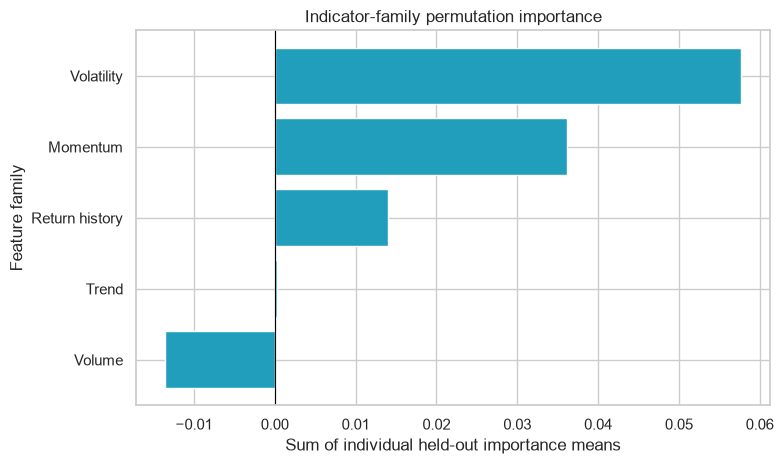

Family values are sums of individual-feature importance means and are not joint family permutation tests.

In [23]:
family_importance = (
    importance.groupby("family", as_index=False)
    .agg(importance_mean=("importance_mean", "sum"), feature_count=("feature", "count"))
    .sort_values("importance_mean", ascending=False)
)
display(family_importance.style.format({"importance_mean": "{:.4f}"}))

ordered_family = family_importance.sort_values("importance_mean")
fig, axis = plt.subplots(figsize=(8, 4.8))
axis.barh(ordered_family["family"], ordered_family["importance_mean"], color="#219EBC")
axis.axvline(0, color="black", linewidth=0.8)
axis.set_title("Indicator-family permutation importance")
axis.set_xlabel("Sum of individual held-out importance means")
axis.set_ylabel("Feature family")
plt.tight_layout()
plt.show()

display(Markdown("Family values are sums of individual-feature importance means and are not joint family permutation tests."))

## Stage 11 Report ready results

Cell ต่อไปสร้างคำตอบ Research Questions จากค่าที่เพิ่งคำนวณ ไม่ใช้ตัวเลขประมาณการหรือข้อความ hard-coded

In [24]:
full_price_change = model_data["Close"].iloc[-1] / model_data["Close"].iloc[0] - 1
full_return_mean = model_data["return_1d"].mean() * 100
full_return_std = model_data["return_1d"].std() * 100
average_volume_millions = model_data["Volume"].mean() / 1_000_000
max_rolling_volatility = model_data["volatility_20"].max() * 100

top_feature = importance.iloc[0]
top_family = family_importance.iloc[0]
rf_row = model_metrics.set_index("model").loc["Random forest"]
baseline_row = model_metrics.set_index("model").loc["Majority baseline"]
best_learned = (
    model_metrics[model_metrics["model"] != "Majority baseline"]
    .sort_values("balanced_accuracy", ascending=False)
    .iloc[0]
)

display(
    Markdown(
        f''' 
### Research Question 1

ช่วง model-ready ตั้งแต่ **{model_data['Date'].min():%Y-%m-%d} ถึง {model_data['Date'].max():%Y-%m-%d}** มีการเปลี่ยนแปลงของราคา Close เท่ากับ **{full_price_change:.2%}** ผลตอบแทนรายวันเฉลี่ย **{full_return_mean:.4f}%** และส่วนเบี่ยงเบนมาตรฐาน **{full_return_std:.4f}%** ปริมาณซื้อขายเฉลี่ย **{average_volume_millions:,.2f} ล้านหุ้นต่อวัน** ขณะที่ค่าสูงสุดของ rolling 20-day daily volatility เท่ากับ **{max_rolling_volatility:.2f}%** ค่าดังกล่าวอธิบายรูปแบบในข้อมูลและไม่ใช่ผลตอบแทนรวมที่ปรับเงินปันผล

### Research Question 2

สำหรับ `{target_model_name}` บน held-out test set ตัวแปรที่มี permutation importance mean สูงสุดคือ **{top_feature['feature']} ({top_feature['importance_mean']:.4f} ± {top_feature['importance_std']:.4f})** และกลุ่มที่มีผลรวมสูงสุดคือ **{top_family['family']} ({top_family['importance_mean']:.4f})** การจัดอันดับขึ้นกับโมเดล ช่วงทดสอบ metric ที่ใช้ และความสัมพันธ์ระหว่าง indicators จึงควรตีความว่าเป็น predictive association

### Research Question 3

Random Forest มี accuracy **{rf_row['accuracy']:.2%}** เทียบกับ majority baseline **{baseline_row['accuracy']:.2%}** หรือแตกต่าง **{(rf_row['accuracy']-baseline_row['accuracy'])*100:+.2f} percentage points** ดังนั้น Random Forest **ไม่ได้ทำ accuracy ดีกว่า baseline** ในช่วงทดสอบนี้ โมเดลที่มี balanced accuracy สูงสุดในกลุ่ม learned models คือ **{best_learned['model']} ({best_learned['balanced_accuracy']:.2%})** แต่ผลนี้ยังต้องอ่านร่วมกับ baseline, ROC AUC, cross-validation variability และข้อเท็จจริงว่า holdout นี้เคยถูกตรวจดูแล้ว

### Limitations

- ข้อมูลเป็น historical OHLCV จาก Nasdaq และราคา Close ที่บันทึกไว้ ไม่ได้ยืนยันว่าเป็น adjusted close หรือ total return
- ไม่มีค่าธรรมเนียม ภาษี bid-ask spread หรือ market impact จึงไม่ใช่การประเมินกลยุทธ์ซื้อขาย
- Permutation importance อธิบายการพึ่งพาตัวแปรของโมเดลที่ fitted แล้ว ไม่ได้พิสูจน์ causality
- ผลจากช่วงเวลาและชุด features นี้อาจไม่คงเดิมเมื่อ regime ตลาดเปลี่ยน
'''
    )
)

 
### Research Question 1

ช่วง model-ready ตั้งแต่ **2021-02-02 ถึง 2026-09-16** มีการเปลี่ยนแปลงของราคา Close เท่ากับ **115.06%** ผลตอบแทนรายวันเฉลี่ย **0.0653%** และส่วนเบี่ยงเบนมาตรฐาน **1.4126%** ปริมาณซื้อขายเฉลี่ย **50.14 ล้านหุ้นต่อวัน** ขณะที่ค่าสูงสุดของ rolling 20-day daily volatility เท่ากับ **3.85%** ค่าดังกล่าวอธิบายรูปแบบในข้อมูลและไม่ใช่ผลตอบแทนรวมที่ปรับเงินปันผล

### Research Question 2

สำหรับ `GradientBoosting` บน held-out test set ตัวแปรที่มี permutation importance mean สูงสุดคือ **atr_14_pct (0.0315 ± 0.0085)** และกลุ่มที่มีผลรวมสูงสุดคือ **Volatility (0.0577)** การจัดอันดับขึ้นกับโมเดล ช่วงทดสอบ metric ที่ใช้ และความสัมพันธ์ระหว่าง indicators จึงควรตีความว่าเป็น predictive association

### Research Question 3

Random Forest มี accuracy **51.59%** เทียบกับ majority baseline **54.77%** หรือแตกต่าง **-3.18 percentage points** ดังนั้น Random Forest **ไม่ได้ทำ accuracy ดีกว่า baseline** ในช่วงทดสอบนี้ โมเดลที่มี balanced accuracy สูงสุดในกลุ่ม learned models คือ **GradientBoosting (52.74%)** แต่ผลนี้ยังต้องอ่านร่วมกับ baseline, ROC AUC, cross-validation variability และข้อเท็จจริงว่า holdout นี้เคยถูกตรวจดูแล้ว

### Limitations

- ข้อมูลเป็น historical OHLCV จาก Nasdaq และราคา Close ที่บันทึกไว้ ไม่ได้ยืนยันว่าเป็น adjusted close หรือ total return
- ไม่มีค่าธรรมเนียม ภาษี bid-ask spread หรือ market impact จึงไม่ใช่การประเมินกลยุทธ์ซื้อขาย
- Permutation importance อธิบายการพึ่งพาตัวแปรของโมเดลที่ fitted แล้ว ไม่ได้พิสูจน์ causality
- ผลจากช่วงเวลาและชุด features นี้อาจไม่คงเดิมเมื่อ regime ตลาดเปลี่ยน


## Stage 12 Reproducibility and cell by cell use

- รันตามลำดับ Stage 1 ถึง Stage 12
- หากแก้ `src/pipeline_qqq_5_year.py` ให้ restart kernel แล้วรันใหม่ตั้งแต่ Stage 1
- Notebook ตรวจ raw SHA-256, จำนวนแถวขั้นต่ำ, chronological order, duplicate dates และ target leakage ก่อนสร้างโมเดล
- ตัวเลขของ `_ex` และ notebook หลักตรงกันเพราะเรียก functions, features และ model settings จาก reference implementation เดียวกัน
- รันอัตโนมัติทั้งไฟล์ได้ด้วย `.venv/bin/python -m jupyter nbconvert --execute --to notebook --inplace notebooks/pipeline_qqq_5_year_ex.ipynb`